In [20]:
import matplotlib as mpl
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [21]:
df = pd.read_csv("results/boot_results_vqa.csv")
df = df.drop(columns=["path", "have_eval_result", "have_prediction", "have_gpt_score", "if_finished", "error"])

df

,model,task,dataset,model_type,trainable_module,model_family,acc,ci_low,ci_high
0,Qwen2-VL,vqa,SLAKE,general,ZS,Qwen,0.779962,0.737981,0.819712
1,Qwen25-VL,vqa,SLAKE,general,ZS,Qwen,0.755822,0.713942,0.798077
2,Gemma3,vqa,SLAKE,general,ZS,Gemma,0.721779,0.680288,0.764423
3,MedGemma,vqa,SLAKE,medical,ZS,Gemma,0.770599,0.730769,0.810096
4,InternVL3,vqa,SLAKE,general,ZS,Intern,0.744175,0.701863,0.786058
...,...,...,...,...,...,...,...,...,...
99,MedGemma,vqa,OmniMedVQA,medical,ML,Gemma,0.929749,0.923052,0.936150
100,InternVL3,vqa,OmniMedVQA,general,ML,Intern,0.967738,0.962977,0.972195
101,LLaVA-1.5,vqa,OmniMedVQA,general,ML,LLaVA,0.903675,0.896056,0.910928
102,LLaVA-Med,vqa,OmniMedVQA,general,ML,LLaVA,NaN,NaN,NaN


In [22]:
df["model_family"].unique()

array(['Qwen', 'Gemma', 'Intern', 'LLaVA', 'Gemini', 'o-family'],
      dtype=object)

# heatmap

In [23]:
df["dataset+tune_module"] = df["dataset"] + "-" + df["trainable_module"]

model_order = [
    "o3",
    "gemini-2.5-pro",
    "LLaVA-1.5",
    "LLaVA-Med",
    "Qwen2-VL",
    "Qwen25-VL",
    "Lingshu",
    "Gemma3",
    "MedGemma",
    # "VILA",
    # "VILA-M3",
    "InternVL3",
]

data_order = [
    "VQA-RAD-ZS",
    "VQA-RAD-ML",
    "PathVQA-ZS",
    "PathVQA-ML",
    "SLAKE-ZS",
    "SLAKE-ML",
    "Harvard-FairVLMed10k-ZS",
    "Harvard-FairVLMed10k-ML",
    "MedXpertQA-ZS",
    "MedXpertQA-ML",
    "OmniMedVQA-ZS",
    "OmniMedVQA-ML",
]

metric = "acc"
df_plot = df.copy(deep=True)
df_plot = df_plot.loc[~df_plot["model"].isin(["VILA", "VILA-M3"])]

df_plot[metric] = df_plot[metric] * 100

data_heatmap = df_plot.pivot(
    index="model", columns="dataset+tune_module", values=metric)
data_heatmap = data_heatmap.reindex(model_order, axis=0)
data_heatmap = data_heatmap.reindex(data_order, axis=1)
data_heatmap

dataset+tune_module,VQA-RAD-ZS,VQA-RAD-ML,PathVQA-ZS,PathVQA-ML,SLAKE-ZS,SLAKE-ML,Harvard-FairVLMed10k-ZS,Harvard-FairVLMed10k-ML,MedXpertQA-ZS,MedXpertQA-ML,OmniMedVQA-ZS,OmniMedVQA-ML
model,,,,,,,,,,,,
o3,78.557371,NaN,75.628227,NaN,81.675240,NaN,53.790882,NaN,NaN,NaN,NaN,NaN
gemini-2.5-pro,61.325100,NaN,75.628227,NaN,87.247837,NaN,54.814529,NaN,NaN,NaN,NaN,NaN
LLaVA-1.5,52.445020,64.586056,54.725193,91.139352,63.995433,83.595433,45.434419,84.751703,NaN,NaN,51.916133,90.367491
LLaVA-Med,69.790837,71.319522,66.000803,83.242921,62.342308,81.474760,76.128808,81.930661,NaN,NaN,20.633463,NaN
Qwen2-VL,75.225498,77.350598,68.274390,92.522100,77.996154,86.096635,58.582064,85.375351,21.79800,31.22850,69.131975,96.632040
Qwen25-VL,70.827092,80.945020,62.358477,92.333849,75.582212,86.319471,61.417134,84.964178,24.00950,28.45250,64.019253,96.311219
Lingshu,70.474900,65.868127,81.527365,63.500565,77.694471,74.022596,66.157164,73.948297,NaN,NaN,83.417087,93.142790
Gemma3,58.247012,61.324701,76.212344,87.179982,72.177885,78.031250,66.645892,83.863176,20.56625,24.71025,36.327918,94.466828
MedGemma,68.387649,75.258167,70.665229,92.646817,77.059856,86.972837,61.613176,84.122996,22.20850,22.87050,69.512868,92.974943


In [24]:
mask = np.zeros_like(data_heatmap, dtype=bool)

mask[:, 6:] = True
mask[2] = True
mask[4] = True
mask[5] = True
mask[7] = True
mask[9] = True
mask[0] = False
mask[1] = False

In [26]:
mask.shape

(10, 12)

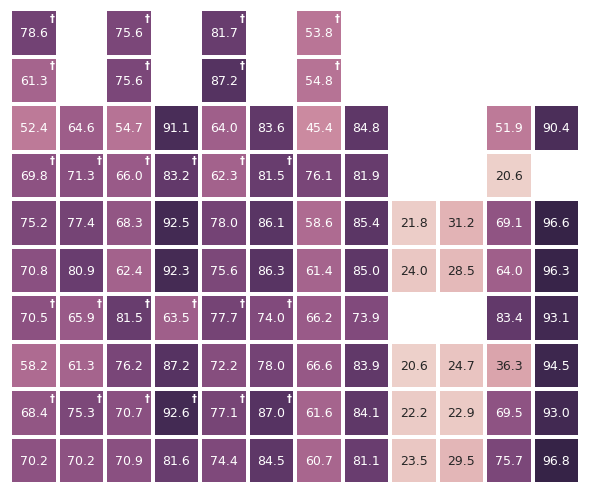

In [30]:
def prepare_annot_for_heatmap(data):
    annot = np.array(data).copy()
    for i in range(annot.shape[0]):
        for j in range(annot.shape[1]):
            annot[i, j] = "{:.1f}".format(float(annot[i, j]))
    return annot


scale = 0.6
fig, ax = plt.subplots(figsize=(mask.shape[0] * scale, mask.shape[1] * scale))

heat = sns.heatmap(
    data_heatmap,
    cbar=False,
    cmap=sns.cubehelix_palette(as_cmap=True),
    annot=prepare_annot_for_heatmap(data_heatmap),
    ax=ax,
    yticklabels=False,
    xticklabels=False,
    fmt="",
    square=True,
    linewidths=2.5 * scale,
    annot_kws={"size": 9},
    vmin=20,
    vmax=100,
)

mask = np.array(mask).astype(bool)


# Add asterisks to the specified cells
for i in range(data_heatmap.shape[0]):
    for j in range(data_heatmap.shape[1]):
        if not mask[i, j]:  # Check if the cell is marked for asterisk
            ax.text(
                j + 0.88,  # Adjust position slightly to the right of the cell
                i + 0.18,  # Center vertically
                "†",
                color="white",  # Asterisk color (contrast with heatmap)
                fontsize=7,
                ha="center",
                va="center",
                weight="bold",
            )

ax.tick_params(right=False, left=True, labelleft=False)
# ax.set_yticks(np.arange(8) + 0.5)
# ax.set_xticks(np.arange(12) + 0.5)
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig(
    "figures/vqa_heatmap",
    dpi=400,
    bbox_inches="tight",
)

,dataset,model,strategy,n,auroc,ci_low,ci_high,is_ood,model_family,model_type
3,Camelyon17,BioMedCLIP,ZS,920,0.772451,0.741732,0.802931,0,CLIP,medical
9,Camelyon17,MedCLIP,ZS,920,0.764455,0.732539,0.794014,1,CLIP,medical
15,Camelyon17,PLIP,ZS,920,0.744498,0.712899,0.773460,0,CLIP,medical
18,Camelyon17,PubMedCLIP,ZS,920,0.330062,0.294766,0.366397,1,CLIP,medical
27,CheXpert,BioMedCLIP,ZS,234,0.605736,0.506624,0.706327,0,CLIP,medical
33,CheXpert,MedCLIP,ZS,234,0.904707,0.847105,0.951765,0,CLIP,medical
39,CheXpert,PLIP,ZS,234,0.467382,0.360284,0.567497,1,CLIP,medical
42,CheXpert,PubMedCLIP,ZS,234,0.766063,0.689597,0.837795,0,CLIP,medical
51,GF3300,BioMedCLIP,ZS,594,0.479033,0.433885,0.525231,1,CLIP,medical
57,GF3300,MedCLIP,ZS,594,0.380748,0.334578,0.427997,1,CLIP,medical


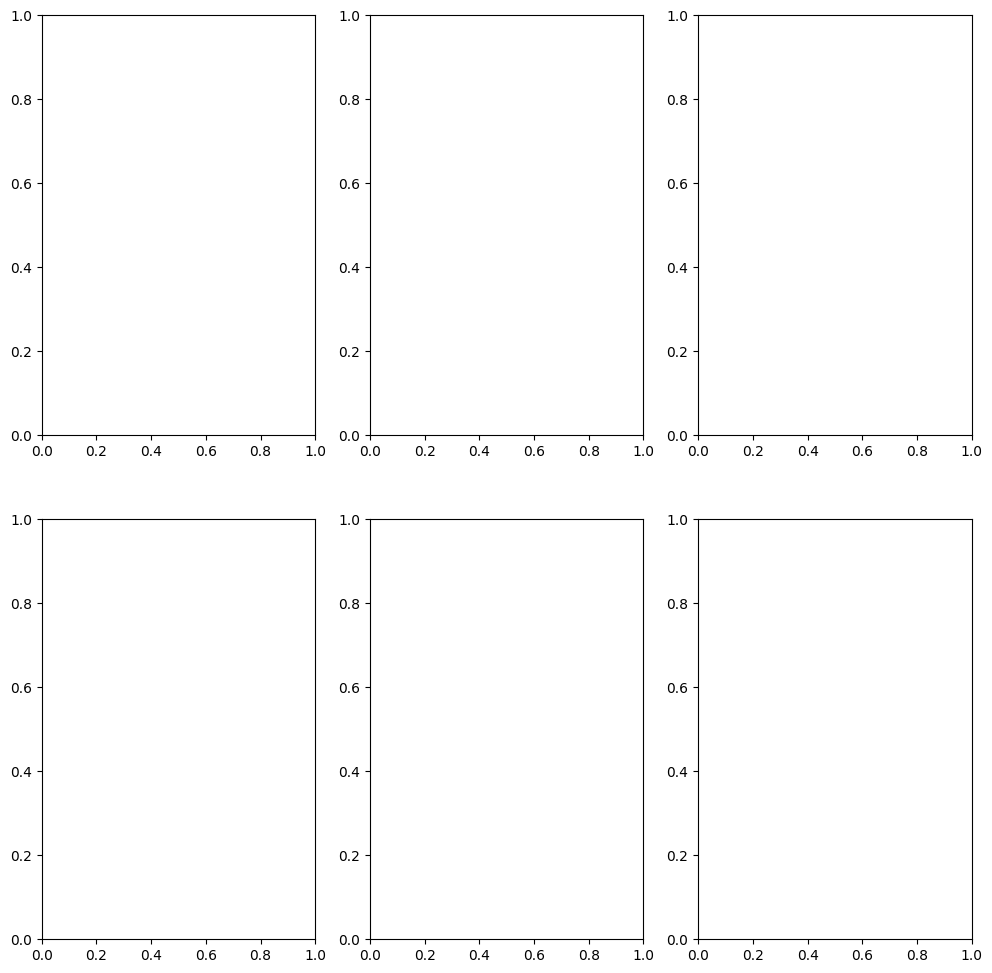

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(12, 12))

for rq in range(1, 4):
    for idx_family, family in enumerate(model_familis):
        cur_ax = axes[idx_family, rq - 1]

        df_sub = df.loc[(df["strategy"].isin(["ZS", "FT-LP"])) & (df["model_family"] == family)]
        if rq == 1:
            df_sub_general = df_sub.loc[(df_sub["model_type"] == "general") & (df_sub["strategy"] == "ZS")]
            df_sub_medical = df_sub.loc[(df_sub["model_type"] == "medical") & (df_sub["strategy"] == "ZS")]
        elif rq == 2:
            df_sub_general = df_sub.loc[(df_sub["model_type"] == "general") & (df_sub["strategy"] == "ZS")]
            df_sub_medical = df_sub.loc[
                (df_sub["model_type"] == "medical") & (df_sub["strategy"] == "ZS") & (df_sub["is_ood"] == 0)
            ]
        elif rq == 3:
            df_sub_general = df_sub.loc[(df_sub["model_type"] == "general") & (df_sub["strategy"] == "ZS")]
            df_sub_medical = df_sub.loc[
                (df_sub["model_type"] == "medical") & (df_sub["strategy"] == "ZS") & (df_sub["is_ood"] == 1)
            ]

        break

    break

df_sub_medical

/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


        Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Accuracy
No. Observations: 36      Method:             REML    
No. Groups:       6       Scale:              0.0002  
Min. group size:  6       Log-Likelihood:     90.4626 
Max. group size:  6       Converged:          Yes     
Mean group size:  6.0                                 
------------------------------------------------------
             Coef. Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------
Intercept    0.776    0.010 78.935 0.000  0.757  0.796
Set[T.Set2]  0.027    0.004  6.047 0.000  0.018  0.035
Group Var    0.001    0.029                           



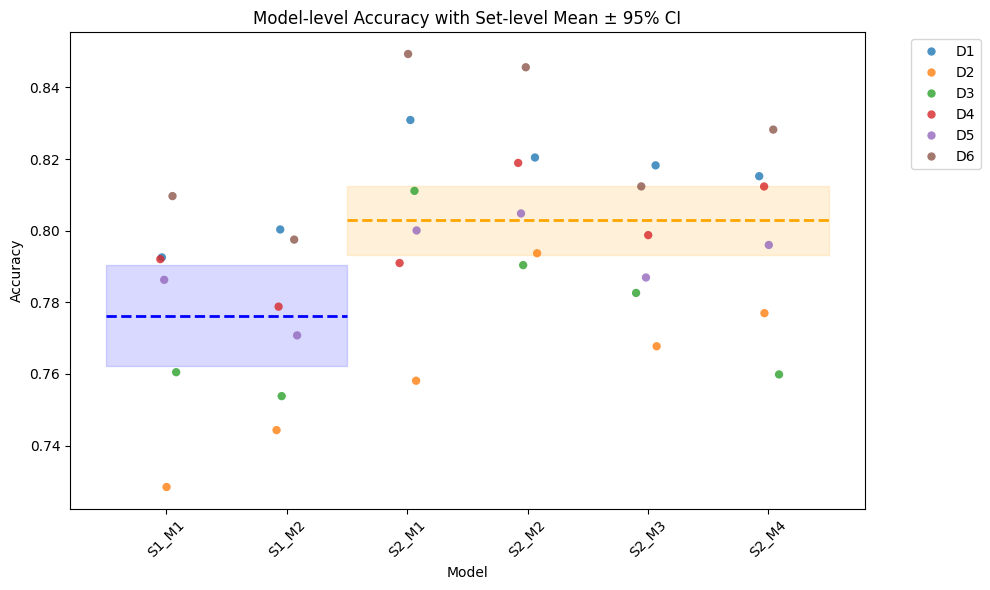

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

np.random.seed(42)

# -----------------------------
# 1. 模拟数据
# -----------------------------


set1_models = ["S1_M1", "S1_M2"]
set2_models = ["S2_M1", "S2_M2", "S2_M3", "S2_M4"]

rows = []

for d in datasets:
    dataset_effect = np.random.normal(0, 0.015)

    # Set1 baseline
    for m in set1_models:
        model_effect = np.random.normal(0, 0.01)
        acc = 0.78 + dataset_effect + model_effect + np.random.normal(0, 0.01)
        rows.append([d, "Set1", m, acc])

    # Set2 slightly better
    for m in set2_models:
        model_effect = np.random.normal(0, 0.01)
        acc = 0.81 + dataset_effect + model_effect + np.random.normal(0, 0.01)
        rows.append([d, "Set2", m, acc])

df = pd.DataFrame(rows, columns=["Dataset", "Set", "Model", "Accuracy"])

# -----------------------------
# 2. Linear Mixed Model
# -----------------------------
# 随机效应：Dataset
# 固定效应：Set

model = smf.mixedlm("Accuracy ~ Set", df, groups=df["Dataset"])

result = model.fit()

print(result.summary())

# -----------------------------
# 3. 计算 set-level mean + CI
# -----------------------------

set_summary = df.groupby("Set")["Accuracy"].agg(["mean", "std", "count"])
set_summary["se"] = set_summary["std"] / np.sqrt(set_summary["count"])
set_summary["ci_low"] = set_summary["mean"] - 1.96 * set_summary["se"]
set_summary["ci_high"] = set_summary["mean"] + 1.96 * set_summary["se"]

# -----------------------------
# 4. 绘图
# -----------------------------

plt.figure(figsize=(10, 6))

# 散点：x=Model, y=Accuracy, 颜色=Dataset
sns.stripplot(data=df, x="Model", y="Accuracy", hue="Dataset", dodge=False, size=6, alpha=0.8)

# 画 set-level mean ± CI 背景带
x_positions = range(len(df["Model"].unique()))
models = df["Model"].unique()

for set_name in set_summary.index:
    mean = set_summary.loc[set_name, "mean"]
    ci_low = set_summary.loc[set_name, "ci_low"]
    ci_high = set_summary.loc[set_name, "ci_high"]

    if set_name == "Set1":
        xmin, xmax = -0.5, 1.5
        color = "blue"
    else:
        xmin, xmax = 1.5, 5.5
        color = "orange"

    plt.fill_between([xmin, xmax], ci_low, ci_high, color=color, alpha=0.15)

    plt.hlines(mean, xmin, xmax, colors=color, linestyles="--", linewidth=2)

plt.title("Model-level Accuracy with Set-level Mean ± 95% CI")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [7]:
df

,Dataset,Set,Model,Accuracy
0,D1,Set1,S1_M1,0.792545
1,D1,Set1,S1_M2,0.800339
2,D1,Set2,S2_M1,0.830901
3,D1,Set2,S2_M2,0.820430
4,D1,Set2,S2_M3,0.818242
5,D1,Set2,S2_M4,0.815213
6,D2,Set1,S1_M1,0.728429
7,D2,Set1,S1_M2,0.744315
8,D2,Set2,S2_M1,0.758098
9,D2,Set2,S2_M2,0.793700
